# 6. Global model with Dinosaur core

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray

from dinosaur import coordinate_systems
from dinosaur import filtering
from dinosaur import primitive_equations
from dinosaur import scales
from dinosaur import sigma_coordinates
from dinosaur import spherical_harmonic
from dinosaur import time_integration
from dinosaur import vertical_interpolation
import dabench as dab

units = scales.units


#### Utilities 

In [3]:
def attach_data_array_units(array):
  attrs = dict(array.attrs)
  units = attrs.pop('units', None)
  if units in {'(0 - 1)', '%', '~'}:
    units = None
  if units is not None:
    data = scales.units.parse_expression(units) * array.data
  else:
    data = scales.units.dimensionless * array.data
  return xarray.DataArray(data, array.coords, array.dims, attrs=attrs)


def attach_xarray_units(ds):
  return ds.map(attach_data_array_units)


def xarray_nondimensionalize(ds):
  return xarray.apply_ufunc(scales.DEFAULT_SCALE.nondimensionalize, ds)


def xarray_to_gcm_dict(ds, var_names=None):
  if var_names is None:
    var_names = ds.keys()
  result = {}
  for var_name in var_names:
    data = ds[var_name].transpose(..., 'longitude', 'latitude').data
    if data.ndim == 2:  # missing level dimension
      data = data[np.newaxis, ...]
    result[var_name] = data
  return result


def slice_levels(output, level_indices):
  def get_horizontal(x):
    if x.shape[0] == 1:
      return x
    else:
      return x[level_indices, ...]
  return jax.tree.map(get_horizontal, output)


#### Configuration

In [4]:
# simulation grid
layers = 4
ref_temp_si = 250 * units.degK
model_coords = coordinate_systems.CoordinateSystem(
    spherical_harmonic.Grid.T21(),
    sigma_coordinates.SigmaCoordinates.equidistant(layers),
)

# timescales
dt_si = 5 * units.minute
save_every = 15 * units.minute
total_time = (0.1 * units.day + save_every)
dfi_timescale = 6 * units.hour

# which levels to output
output_level_indices = np.arange(layers) #[layers // 4, layers // 2, 3*layers // 4, -1]

#### Load source data

In [5]:
def open_era5(path, time):
  ds = xarray.open_zarr(path, chunks=None, storage_options=dict(token='anon'))
  return ds.sel(time=time)


ds_arco_era5 = xarray.merge([
    open_era5('gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3', time='19900501T00').drop_dims('level'),
    open_era5('gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1', time='19900501T00'),
])

ds = ds_arco_era5[[
    'u_component_of_wind',
    'v_component_of_wind',
    'temperature',
    'specific_humidity',
    'specific_cloud_liquid_water_content',
    'specific_cloud_ice_water_content',
    'surface_pressure',
]]

raw_orography = ds_arco_era5.geopotential_at_surface

desired_lon = 180/np.pi * model_coords.horizontal.nodal_axes[0]
desired_lat = 180/np.pi * np.arcsin(model_coords.horizontal.nodal_axes[1])

ds_init = attach_xarray_units(ds.compute().interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] = attach_data_array_units(raw_orography.interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] /= scales.GRAVITY_ACCELERATION

source_vertical = vertical_interpolation.HybridCoordinates.ECMWF137()

#### Initial conditions

In [6]:
# nondimensionalize

ds_nondim_init = xarray_nondimensionalize(ds_init)
model_level_inputs = xarray_to_gcm_dict(ds_nondim_init)

sp_nodal = model_level_inputs.pop('surface_pressure')
orography_input = model_level_inputs.pop('orography')

sp_init_hpa = ds_init.surface_pressure.transpose('longitude', 'latitude').data.to('hPa').magnitude
foo = ds_init.surface_pressure.transpose('longitude', 'latitude').data

# build inputs
physics_specs = primitive_equations.PrimitiveEquationsSpecs.from_si()

nodal_inputs = vertical_interpolation.regrid_hybrid_to_sigma(
    fields=model_level_inputs,
    hybrid_coords=source_vertical,
    sigma_coords=model_coords.vertical,
    surface_pressure=sp_init_hpa,
)
u_nodal = nodal_inputs['u_component_of_wind']
v_nodal = nodal_inputs['v_component_of_wind']
t_nodal = nodal_inputs['temperature']

# calculate vorticity & divergence
vorticity, divergence = spherical_harmonic.uv_nodal_to_vor_div_modal(
    model_coords.horizontal, u_nodal, v_nodal
)

# apply reference temperature
ref_temps = physics_specs.nondimensionalize(
    ref_temp_si * np.ones((model_coords.vertical.layers,))
)

assert ref_temps.shape == (model_coords.vertical.layers,)
temperature_variation = model_coords.horizontal.to_modal(
    t_nodal - ref_temps.reshape(-1, 1, 1)
)

log_sp = model_coords.horizontal.to_modal(np.log(sp_nodal))
tracers = model_coords.horizontal.to_modal(
    {
        'specific_humidity': nodal_inputs['specific_humidity'],
        'specific_cloud_liquid_water_content': nodal_inputs['specific_cloud_liquid_water_content'],
        'specific_cloud_ice_water_content': nodal_inputs['specific_cloud_ice_water_content'],
    }
)

# build initial state
raw_init_state = primitive_equations.State(
    vorticity=vorticity,
    divergence=divergence,
    temperature_variation=temperature_variation,
    log_surface_pressure=log_sp,
    tracers=tracers,
)

orography = model_coords.horizontal.to_modal(orography_input)
orography = filtering.exponential_filter(model_coords.horizontal, order=2)(orography)


#### Setup dycore

In [7]:
# setup a simulation of the dry primitive equations
eq = primitive_equations.PrimitiveEquations(
    ref_temps, orography, model_coords, physics_specs
)

# setup hyper-spectral filter for running between dycore time-steps
res_factor = model_coords.horizontal.latitude_nodes / 128
dt = physics_specs.nondimensionalize(dt_si)
tau = physics_specs.nondimensionalize(8.6 / (2.4 ** np.log2(res_factor)) * units.hours)
hyperdiffusion_filter = time_integration.horizontal_diffusion_step_filter(
    model_coords.horizontal, dt=dt, tau=tau, order=2
)

# digital filter initialization
time_span = cutoff_period = physics_specs.nondimensionalize(dfi_timescale)
dfi = jax.jit(time_integration.digital_filter_initialization(
    equation=eq,
    ode_solver=time_integration.imex_rk_sil3,
    filters=[hyperdiffusion_filter],
    time_span=time_span,
    cutoff_period=cutoff_period,
    dt=dt,
))
%time dfi_init_state = jax.block_until_ready(dfi(raw_init_state))

CPU times: user 24.1 s, sys: 132 ms, total: 24.2 s
Wall time: 24.2 s


#### Time integration and postprocessing

In [8]:
# time integration & post-processing

def nodal_prognostics_and_diagnostics(state):
  coords = model_coords.horizontal
  u_nodal, v_nodal = spherical_harmonic.vor_div_to_uv_nodal(
      coords, state.vorticity, state.divergence)
  geopotential_nodal = coords.to_nodal(
      primitive_equations.get_geopotential(
          state.temperature_variation,
          eq.reference_temperature,
          orography,
          model_coords.vertical,
          physics_specs.gravity_acceleration,
          physics_specs.ideal_gas_constant,
      )
  )
  vor_nodal = coords.to_nodal(state.vorticity)
  div_nodal = coords.to_nodal(state.divergence)
  sp_nodal = jnp.exp(coords.to_nodal(state.log_surface_pressure))
  tracers_nodal = {k: coords.to_nodal(v) for k, v in state.tracers.items()}
  t_nodal = (
      coords.to_nodal(state.temperature_variation)
      + ref_temps[:, np.newaxis, np.newaxis]
  )
  vertical_velocity_nodal = primitive_equations.compute_vertical_velocity(
      state, model_coords
  )
  state_nodal = {
      'u_component_of_wind': u_nodal,
      'v_component_of_wind': v_nodal,
      'temperature': t_nodal,
      'vorticity': vor_nodal,
      'divergence': div_nodal,
      'vertical_velocity': vertical_velocity_nodal,
      'geopotential': geopotential_nodal,
      'surface_pressure': sp_nodal,
      **tracers_nodal,
  }
  return slice_levels(state_nodal, output_level_indices)


def trajectory_to_xarray(trajectory):

  # convert units back to SI
  target_units = {k: v.data.units for k, v in ds_init.items()}
  target_units |= {
      'vorticity': units('1/s'),
      'divergence': units('1/s'),
      'geopotential': units('m^2/s^2'),
      'vertical_velocity': units('1/s'),
  }

  orography_nodal = jax.device_put(model_coords.horizontal.to_nodal(orography), device=jax.devices('cpu')[0])
  trajectory_cpu = jax.device_put(trajectory, device=jax.devices('cpu')[0])

  traj_nodal_si = {
      k: physics_specs.dimensionalize(v, target_units[k]).magnitude
      for k, v in trajectory_cpu.items()
  }

  # build xarray
  times = float(save_every / units.hour) * np.arange(outer_steps)
  lon = 180/np.pi * model_coords.horizontal.nodal_axes[0]
  lat = 180/np.pi * np.arcsin(model_coords.horizontal.nodal_axes[1])

  dims = ('time', 'sigma', 'longitude', 'latitude')
  ds_result = xarray.Dataset(
      data_vars={
          k: (dims, v) for k, v in traj_nodal_si.items() if k != 'surface_pressure'
      },
      coords={
          'longitude': lon,
          'latitude': lat,
          'sigma': model_coords.vertical.centers[output_level_indices],
          'time': times,
          'orography': (('longitude', 'latitude'), orography_nodal.squeeze()),
      },
  ).assign(
      surface_pressure=(
          ('time', 'longitude', 'latitude'),
          traj_nodal_si['surface_pressure'].squeeze(axis=-3),
      )
  )
  return ds_result

# temporal integration function
inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)
step_fn = time_integration.step_with_filters(
    time_integration.imex_rk_sil3(eq, dt),
    [hyperdiffusion_filter],
)
integrate_fn = jax.jit(time_integration.trajectory_from_step(
    step_fn,
    outer_steps=outer_steps,
    inner_steps=inner_steps,
    start_with_input=True,
    post_process_fn=nodal_prognostics_and_diagnostics,
))


#### Run output

In [9]:
%time out_state, trajectory = jax.block_until_ready(integrate_fn(dfi_init_state))
ds_out = trajectory_to_xarray(trajectory)


CPU times: user 16.5 s, sys: 165 ms, total: 16.6 s
Wall time: 16.6 s


In [10]:
# %time out_state, trajectory = jax.block_until_ready(integrate_fn(raw_init_state))
# ds_out_unfiltered = trajectory_to_xarray(trajectory)

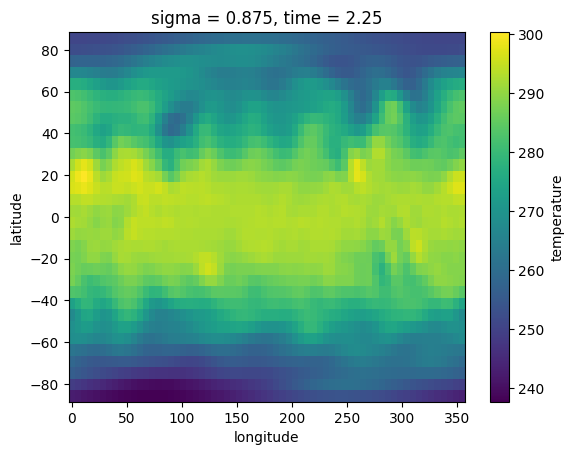

In [11]:
ds_out['temperature'].isel(time=9, sigma=3).plot(x='longitude')

#### Attempting a forecast function

In [ ]:
def full_prep(ds_init):
    orography_var = ds_init['orography']
    ds_init['surface_pressure'] = ds_init['surface_pressure'].isel(sigma=0)
    ds_with_units = attach_xarray_units(ds_init.drop_vars('orography'))
    ds_with_units['orography'] = attach_data_array_units(orography_var)
    ds_with_units['orography'] /= scales.GRAVITY_ACCELERATION
    ds_nondim_init = xarray_nondimensionalize(ds_with_units)

    source_vertical = vertical_interpolation.HybridCoordinates.ECMWF137()

    model_level_inputs = xarray_to_gcm_dict(ds_nondim_init)

    sp_nodal = model_level_inputs.pop('surface_pressure')
    orography_input = model_level_inputs.pop('orography')

    # Surface pressure has no actual sigma, so here we can select any level (it's been broadcast to match other vairables)
    sp_init_hpa = ds_with_units.surface_pressure.transpose('longitude', 'latitude').data/100#.to('hPa').magnitude

    # build inputs
    physics_specs = primitive_equations.PrimitiveEquationsSpecs.from_si()

    nodal_inputs = model_level_inputs 
    u_nodal = nodal_inputs['u_component_of_wind']
    v_nodal = nodal_inputs['v_component_of_wind']
    t_nodal = nodal_inputs['temperature']

    # calculate vorticity & divergence
    vorticity, divergence = spherical_harmonic.uv_nodal_to_vor_div_modal(
        model_coords.horizontal, u_nodal, v_nodal
    )

    # apply reference temperature
    ref_temps = physics_specs.nondimensionalize(
        ref_temp_si * np.ones((model_coords.vertical.layers,))
    )

    assert ref_temps.shape == (model_coords.vertical.layers,)
    temperature_variation = model_coords.horizontal.to_modal(
        t_nodal - ref_temps.reshape(-1, 1, 1)
    )

    log_sp = model_coords.horizontal.to_modal(jnp.log(sp_nodal))
    tracers = model_coords.horizontal.to_modal(
        {
            'specific_humidity': nodal_inputs['specific_humidity'],
            'specific_cloud_liquid_water_content': nodal_inputs['specific_cloud_liquid_water_content'],
            'specific_cloud_ice_water_content': nodal_inputs['specific_cloud_ice_water_content'],
        }
    )

    # build initial state
    raw_init_state = primitive_equations.State(
        vorticity=vorticity,
        divergence=divergence,
        temperature_variation=temperature_variation,
        log_surface_pressure=log_sp,
        tracers=tracers,
    )
    
    full_init_state = dfi(raw_init_state)
    return full_init_state

In [13]:
class DinoModel(dab.model.Model):

    def forecast(self, ds_init, n_steps=1):
        # temporal integration function
        dfi_init_state = full_prep(ds_init)
        inner_steps = int(save_every / dt_si)
        outer_steps = int(total_time / save_every)
        step_fn = time_integration.step_with_filters(
            time_integration.imex_rk_sil3(eq, dt),
            [hyperdiffusion_filter],
        )
        integrate_fn = jax.jit(time_integration.trajectory_from_step(
            step_fn,
            outer_steps=outer_steps,
            inner_steps=inner_steps,
            start_with_input=True,
            post_process_fn=nodal_prognostics_and_diagnostics,
        ))
        out_state, trajectory = jax.block_until_ready(integrate_fn(dfi_init_state))
        ds_out = trajectory_to_xarray(trajectory)
        ds_out = ds_out.assign_attrs(system_dim=ds_init.system_dim)
        ds_out = ds_out.assign(surface_pressure=xarray.broadcast(ds_out['temperature'], ds_out['surface_pressure'])[1])
        return ds_out.isel(time=-1), ds_out

fc_model = DinoModel()

In [14]:
sizes = [ds_out.sizes[s] for s in ds_out.sizes if s != 'time']

In [15]:
ds_out = ds_out.assign_attrs(system_dim=np.prod(sizes)*11)

In [16]:
ds_full = ds_out.assign(surface_pressure=xarray.broadcast(ds_out['temperature'], ds_out['surface_pressure'])[1])

In [17]:
observer = dab.observer.Observer(
    ds_full.as_numpy(), # prevents indexing failure
    error_sd=10,
    random_location_density=0.5,
    random_time_density=0.5
    )
observations = observer.observe()

In [18]:
# Try da cycler
dc=dab.dacycler.Var3D(
    system_dim=ds_full.system_dim,
    model_obj=fc_model,
    delta_t=0.25
)
out_var3d = dc.cycle(
    input_state = ds_full.isel(time=0),
    start_time = 0.0,
    obs_vector = observations,
    obs_error_sd = 15, 
    analysis_window=1.0,
    n_cycles=1,
    return_forecast=False
    )

/home/ksolvik/miniconda3/envs/dab-dino/lib/python3.11/site-packages/xarray_jax/custom_types.py:160: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(
/home/ksolvik/miniconda3/envs/dab-dino/lib/python3.11/site-packages/xarray_jax/custom_types.py:160: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(


In [19]:
# NOTE: It is outputting all zeros now, but if you edit _dacycler.py and return the whole dataset
# (not filtered by timestep using isel) you will get an out of memory error.
# I suspect the computations are not actually happening, because they're prohibitively expensive.
out_var3d

<xarray.Dataset> Size: 721kB
Dimensions:                              (cycle: 1, sigma: 4, longitude: 64,
                                          latitude: 32)
Dimensions without coordinates: cycle, sigma, longitude, latitude
Data variables:
    divergence                           (cycle, sigma, longitude, latitude) float64 66kB ...
    geopotential                         (cycle, sigma, longitude, latitude) float64 66kB ...
    specific_cloud_ice_water_content     (cycle, sigma, longitude, latitude) float64 66kB ...
    specific_cloud_liquid_water_content  (cycle, sigma, longitude, latitude) float64 66kB ...
    specific_humidity                    (cycle, sigma, longitude, latitude) float64 66kB ...
    surface_pressure                     (cycle, sigma, longitude, latitude) float64 66kB ...
    temperature                          (cycle, sigma, longitude, latitude) float64 66kB ...
    u_component_of_wind                  (cycle, sigma, longitude, latitude) float64 66kB ...
    v_component_of_wind                  (cycle, sigma, longitude, latitude) float64 66kB ...
    vertical_velocity                    (cycle, sigma, longitude, latitude) float64 66kB ...
    vorticity                            (cycle, sigma, longitude, latitude) float64 66kB ...